# Import libraries

In [1]:
import numpy as np
import json
from sklearn.decomposition import PCA
from helpers.grid import deme_id, decode_deme, create_grid
from helpers.tree import simulate_tree, drop_mutations, get_descendants, build_ancestral_genotype
from helpers.vizualisation import build_deme_colors, visualize_grid, visualize_pca, visualize_multiple_plots

# Parameters

In [2]:
with open("../params.json") as f:
    params = json.load(f)

In [3]:
k           = params["k"]
Ne          = params["Ne"]
M           = params["M"]
n_per_deme  = params["n_per_deme"]
n_loci      = params["n_loci"]
n_mutations = params["n_mutations"]
random_seed = params["random_seed"]

In [4]:

rng = np.random.default_rng(random_seed)

n_demes     = k * k
n_samples   = n_demes * n_per_deme   # total haplotypes

In [5]:
m = M / (2*Ne)

In [6]:
# Ancestral is very large and weakly connected

In [7]:
m 

2.5e-05

# Create grid

In [8]:
grid, neighbors = create_grid(k)

In [9]:
print(grid)

[[2 3 3 3 3 3 3 3 3 2]
 [3 4 4 4 4 4 4 4 4 3]
 [3 4 4 4 4 4 4 4 4 3]
 [3 4 4 4 4 4 4 4 4 3]
 [3 4 4 4 4 4 4 4 4 3]
 [3 4 4 4 4 4 4 4 4 3]
 [3 4 4 4 4 4 4 4 4 3]
 [3 4 4 4 4 4 4 4 4 3]
 [3 4 4 4 4 4 4 4 4 3]
 [2 3 3 3 3 3 3 3 3 2]]


In [10]:
G = build_ancestral_genotype(n_loci, k, n_per_deme, Ne, M, neighbors, rng, n_mutations)

  locus 0/2000...
  locus 50/2000...
  locus 100/2000...
  locus 150/2000...
  locus 200/2000...
  locus 250/2000...
  locus 300/2000...
  locus 350/2000...
  locus 400/2000...
  locus 450/2000...
  locus 500/2000...
  locus 550/2000...
  locus 600/2000...
  locus 650/2000...
  locus 700/2000...
  locus 750/2000...
  locus 800/2000...
  locus 850/2000...
  locus 900/2000...
  locus 950/2000...
  locus 1000/2000...
  locus 1050/2000...
  locus 1100/2000...
  locus 1150/2000...
  locus 1200/2000...
  locus 1250/2000...
  locus 1300/2000...
  locus 1350/2000...
  locus 1400/2000...
  locus 1450/2000...
  locus 1500/2000...
  locus 1550/2000...
  locus 1600/2000...
  locus 1650/2000...
  locus 1700/2000...
  locus 1750/2000...
  locus 1800/2000...
  locus 1850/2000...
  locus 1900/2000...
  locus 1950/2000...


In [11]:
G_f    = G.T.astype(float)
std    = G_f.std(axis=0); std[std == 0] = 1
G_std  = (G_f - G_f.mean(axis=0)) / std
pca    = PCA(n_components=2)
coords = pca.fit_transform(G_std)

In [12]:
G

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(2000, 10000), dtype=int8)

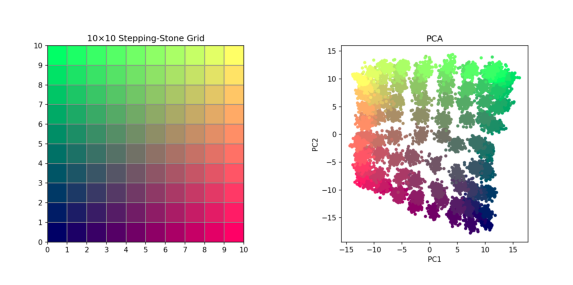

In [13]:
deme_colors = build_deme_colors(k)
sample_demes = np.repeat(np.arange(n_demes), n_per_deme)
hap_colors   = [deme_colors[d] for d in sample_demes]

fig_grid = visualize_grid(n_demes, k, deme_colors)
fig_pca  = visualize_pca(hap_colors, coords)
visualize_multiple_plots([fig_grid, fig_pca], figsize_each=(2, 2))

# Save data

In [14]:
fname = f"data/G_k{k}_Ne{Ne}_M{M}_npd{n_per_deme}_nloc{n_loci}_seed{random_seed}.npz"

np.savez_compressed(fname, G=G)